## Import Library

In [1]:
import pandas as pd
import joblib
from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

## Load ML models and extract Database

In [2]:
BASE_PATH = Path.cwd().parent
MODEL_PATH = BASE_PATH / "database" / "model_artifacts"
DATA_PATH = BASE_PATH / "database" / "fix_final_hospital_database.parquet"

# Load each .joblib file in the model_artifacts directory and store them in a dictionary
models = {}
for model_file in MODEL_PATH.glob("*.joblib"):
    model_name = model_file.stem
    models[model_name] = joblib.load(model_file)
    print(f"Loaded model: {model_name} from {model_file}")

# Load database
df = pd.read_parquet(DATA_PATH)
print(f"Loaded database from {DATA_PATH} with shape: {df.shape}")

Loaded model: logistic_regression from /Users/miftahhadiyannoor/Documents/Hospital_healthcare/develop/database/model_artifacts/logistic_regression.joblib
Loaded model: gradient_boosting from /Users/miftahhadiyannoor/Documents/Hospital_healthcare/develop/database/model_artifacts/gradient_boosting.joblib
Loaded model: random_forest from /Users/miftahhadiyannoor/Documents/Hospital_healthcare/develop/database/model_artifacts/random_forest.joblib
Loaded model: xgboost from /Users/miftahhadiyannoor/Documents/Hospital_healthcare/develop/database/model_artifacts/xgboost.joblib
Loaded model: decision_tree from /Users/miftahhadiyannoor/Documents/Hospital_healthcare/develop/database/model_artifacts/decision_tree.joblib
Loaded database from /Users/miftahhadiyannoor/Documents/Hospital_healthcare/develop/database/fix_final_hospital_database.parquet with shape: (10000, 20)


## Encoded database

In [3]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
le = LabelEncoder()

# Encode categorical variables
for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

## Split data into X features and y Target

In [4]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['arrival_date', 'departure_date', 'patient_churn', 'name'])
y = df_encoded['patient_churn']

# Split the dataset into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Training set class distribution:\n{y_train.value_counts(normalize=True)}")

Training set size: 8000 samples
Testing set size: 2000 samples
Training set class distribution:
patient_churn
1    0.60275
0    0.39725
Name: proportion, dtype: float64


## Unwrap the models if wrapped as dict_values([{...}, {...}, ...])

In [5]:
if len(models) == 1 and isinstance(next(iter(models.values())), list):
    models = {f"model_{i}": m for i, m in enumerate(next(iter(models.values())))}

## Reorder the model to match training feature order

In [6]:
first_model = next(iter(models.values()))['model']
if hasattr(first_model, 'feature_names_in_'):
    X = X[list(first_model.feature_names_in_)]

## Implementing ML models prediction to Database
* ### Get the reasoning to match with LLM by ML models
* ### Returning the result to fetch with Agentic AI

In [7]:
results = df[['patient_id']].copy()
for name, entry in models.items():
    mdl = entry['model']

    # Apply to the results DataFrame
    results[f'{name}_prediction'] = mdl.predict(X)
    if hasattr(mdl, 'predict_proba'):
        results[f'{name}_probability'] = mdl.predict_proba(X)[:, 1].round(4)

    print(f"Predictions and probabilities added for model: {name}")

Predictions and probabilities added for model: logistic_regression
Predictions and probabilities added for model: gradient_boosting
Predictions and probabilities added for model: random_forest
Predictions and probabilities added for model: xgboost
Predictions and probabilities added for model: decision_tree


In [8]:
# Add the real churn values to the results DataFrame
results = results.merge(df[['patient_id', 'patient_churn']], on='patient_id', how='left')

pred_cols = [c for c in results.columns if c.endswith('_prediction')]
prob_cols = [c for c in results.columns if c.endswith('_probability')]
results['churn_majority_vote'] = (results[pred_cols].mean(axis=1) >= -0.5).astype(int)
results['churn_avg_probability'] = results[prob_cols].mean(axis=1).round(4)


# Merge the results
df_predicted = df.merge(results, on='patient_id', how='left')

## Compare ML models on real values

# 

In [9]:
results[['patient_id', 'logistic_regression_prediction', 'gradient_boosting_prediction', 'random_forest_prediction', 'patient_churn']].head()

,patient_id,logistic_regression_prediction,gradient_boosting_prediction,random_forest_prediction,patient_churn
0,PAT-09484753,1,1,1,1
1,PAT-f0644084,0,0,0,0
2,PAT-ac6162e4,1,1,1,1
3,PAT-3dda2bb5,1,1,1,1
4,PAT-08591375,0,0,0,0


In [10]:
results.describe()

,logistic_regression_prediction,logistic_regression_probability,gradient_boosting_prediction,gradient_boosting_probability,random_forest_prediction,random_forest_probability,xgboost_prediction,xgboost_probability,decision_tree_prediction,decision_tree_probability,patient_churn,churn_majority_vote,churn_avg_probability
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0,10000.000000
mean,0.591900,0.603201,0.602600,0.602629,0.602100,0.602667,0.602600,0.602768,0.602700,0.602700,0.602800,1.0,0.602794
std,0.491506,0.452291,0.489385,0.488992,0.489489,0.465325,0.489385,0.487353,0.489364,0.489364,0.489343,0.0,0.471216
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.039200,0.000000,0.000000,0.000000,0.022500,0.000000,0.000200,0.000000,0.000000,0.000000,1.0,0.014000
50%,1.000000,0.974000,1.000000,1.000000,1.000000,0.974200,1.000000,0.999800,1.000000,1.000000,1.000000,1.0,0.987700
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


## Data visualization to analyze hospital

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Merge predictions back into main df
df_new = df.merge(results[['patient_id',
                       'logistic_regression_prediction',
                       'gradient_boosting_prediction',
                       'random_forest_prediction']],
              on='patient_id', how='left')

## Patient analytics

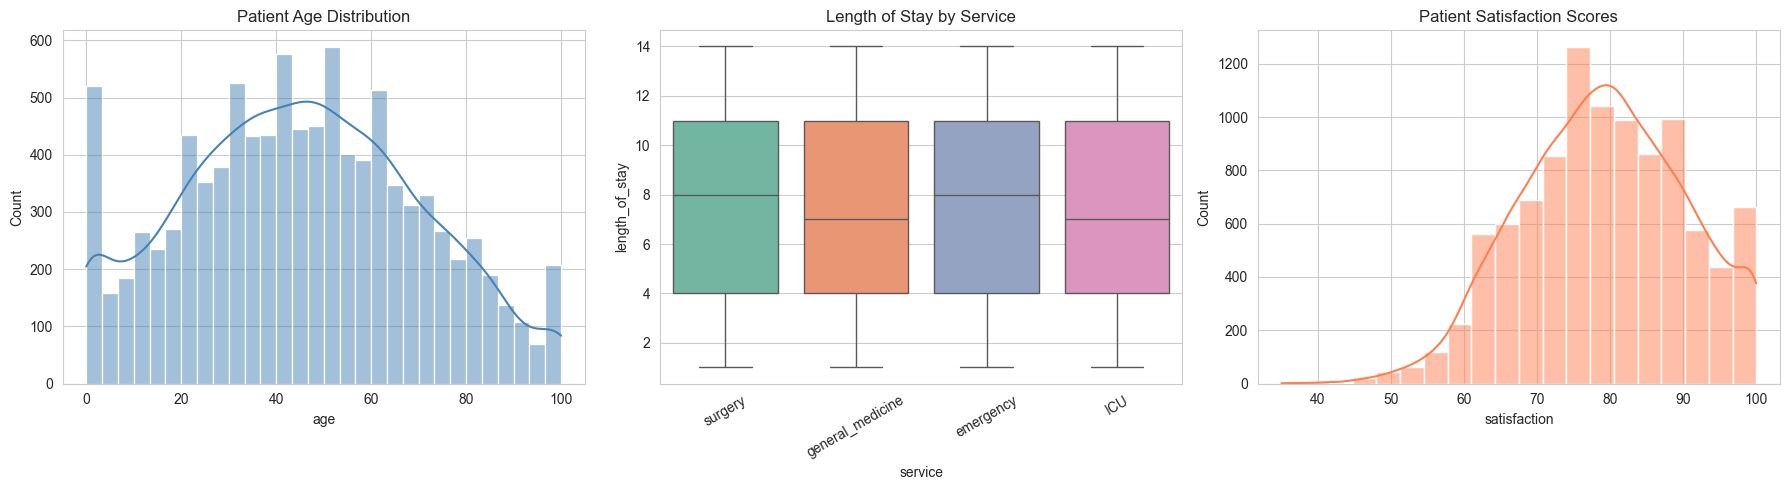

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age distribution
sns.histplot(df_new['age'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Patient Age Distribution')
    
# Length of stay by service
sns.boxplot(data=df_new, x='service', y='length_of_stay', ax=axes[1], palette='Set2')
axes[1].set_title('Length of Stay by Service')
axes[1].tick_params(axis='x', rotation=30)

# Satisfaction score distribution
sns.histplot(df['satisfaction'], bins=20, kde=True, ax=axes[2], color='coral')
axes[2].set_title('Patient Satisfaction Scores')

plt.tight_layout() 
plt.show()